## Module 4: *(Template)*

## Team Members:
Vish Ramineni, Kat Horn

## Project Title:
Identifying Demographic Patterns in Apoptosis Resistance Among Lung Squamous Cell Carcinoma Patients

## Project Goal:
This project seeks to answer 3 questions: 
1. Are late-stage LUSC tumors associated with higher anti-apoptotic signaling compared to early-stage tumors across demographic groups?
2. Are there sex, smoking, or family history-related differences in proliferative signaling and apoptosis pathways in LUSC tumors?
3. Which demographic factor (age, gender, or smoking) is the strongest predictor of apoptosis resistance in LUSC?



## Disease Background:

Resisting cell death is a key hallmark of cancer in which tumor cells evade apoptosis, the body’s natural process for eliminating damaged or abnormal cells. In healthy tissues, apoptosis is triggered by signals such as DNA damage, oxidative stress, or abnormal growth signals, ensuring that potentially harmful cells do not survive. This process is tightly regulated by a network of genes and signaling pathways that maintain normal tissue balance. When these pathways function properly, they act as a safeguard against cancer development.

In lung squamous cell carcinoma, this protective mechanism is disrupted, allowing cells that should undergo apoptosis to survive. Mutations in critical genes, such as TP53, or changes in the expression of apoptosis-regulating proteins, like those in the BCL2 family, interfere with the signaling pathways that normally initiate cell death. As a result, damaged cells continue to live and accumulate additional mutations, contributing to tumor growth and progression. This resistance to apoptosis also makes cancer cells less responsive to treatments like chemotherapy and radiation, which rely on triggering cell death.

Although resisting cell death alone is not sufficient for cancer to spread or metastasize, it plays an essential enabling role. By allowing abnormal cells to persist, it creates the conditions necessary for other cancer hallmarks, such as sustained proliferation and invasion, to develop. As emphasized in the course material, multiple hallmarks must work together for full cancer progression, but the ability to evade apoptosis is a critical early step that supports the survival and expansion of cancer cells.

Lung cancer is one of the most common cancers worldwide and remains the leading cause of cancer-related death, with lung squamous cell carcinoma (LUSC) representing about 20–30% of all lung cancer cases. This subtype is strongly associated with cigarette smoking, which is the primary risk factor, along with secondhand smoke exposure and environmental or occupational carcinogens such as asbestos and radon. Genetic mutations, particularly in tumor suppressor genes like TP53 and other apoptosis-regulating genes, also contribute to disease development. In addition, societal factors such as socioeconomic status, occupational exposures, and access to healthcare and early screening play an important role in both incidence and outcomes. Standard treatment options for LUSC include chemotherapy, radiotherapy, and increasingly immunotherapy, all of which aim to eliminate cancer cells, often by inducing cell death pathways. However, resistance to apoptosis can reduce treatment effectiveness. Biologically, LUSC arises in the epithelial lining of the bronchi, where repeated exposure to harmful substances leads to cellular damage, disruption of normal apoptosis signaling, and the survival of abnormal cells that continue to grow and accumulate further mutations.

sources: https://www.ncbi.nlm.nih.gov/books/NBK564510/, Dr. Groves Slides

## Data-Set: 

We will be looking at the cancer Lung Squamous Cell Sarcinoma specifically. The genes we will be looking at include those that are connected to Resisting Cell death (apoptosis). These genes include: 
 ATP2B2, FAM155A, KCNIP3, TAC1, ALX4, TTLL6, MUC12, IFI6, HRK, C15orf41, PRSS53, CPE, KIAA1671, SLC7A3, UBXN10, UNC93B1, USP2

The question we will be investigating is: Can LUSC patients be clustered based on apoptosis-related gene expression, and do these clusters differ by smoking status, age, or gender? Furthermore, Which demographic factor (age, gender, or smoking) is the strongest predictor of apoptosis resistance in LUSC?

History points we will take into account is packs_per_year_smoked, age_at_diagnosis, and gender. We will use these factors to nuance our investigative question to get a comprehensive view of the cancer. 

Data being used:
- Survival data for each sample from Pan-Cancer Clinical Data Resource (Liu et al. 2018)
    - This gives overall survival which is the epriod from the date of diagnosis until the date of death from any cause
    - Disease-specific survival: death from the diagnosed cancer type - This will be useful
    - Progression-free interval - the period from the date of diagnosis until the date of the first occurrence of a new tumor event
    - Disease-free interval - the period from the date of diagnosis until the date of the first new tumor progression event subsequent to the determination of a patient's disease-free status after their initial diagnosis treatment. 
- Cancer Genome Atlas RNA-seq dataset (Rahman et al. )
    - this gives data on 24 cancer types
    - Data collection method - SANGER SEQUENCING explained below

Sanger Sequencing
- Uses dideoxynucleotides that bind to a building DNA sequence. These also are able to be read during sequencing after gel electrophoresis. Strands that are longer migrate a shorter distance. When you align all these reads together and see where the peaks are and what color they correspond to regarding dideoxynucleotides, the sequence of the DNA can be deduced. 
- The DNA being talked about here is actually RNA that was converted into cDNA. Finally, longer genes will generate more fragments, so it is important to normalize by gene length. Then, tumor samples won't all have the same total number of reads to normalize by library size, giving TPM. So, our data is log-transformed TPM values. 

or this analysis, we will focus specifically on lung squamous cell carcinoma (LUSC) samples from the Cancer Genome Atlas (TCGA) RNA-seq dataset. Rather than analyzing all 24 cancer types, restricting the dataset to a single cancer type allows for a more controlled investigation of how gene expression relates to survival outcomes within a consistent biological context.

We will examine expression levels of genes associated with two cancer hallmarks: sustaining proliferative signaling (ALK, BRAF, CDK4) and resisting cell death (ALK, BCL2, BRAF). These genes were selected because they play key roles in regulating cell growth and apoptosis, and some (like ALK and BRAF) overlap between hallmarks, making them especially interesting for studying combined effects.

In addition to gene expression data, we will incorporate relevant clinical metadata to better understand patient outcomes. The clinical features included in this analysis are: Smoking history (tobacco starting age), pathologic tumor stage, and gender.

These variables were chosen because they are known to influence lung cancer progression and survival, and they will help refine our analysis by accounting for patient-specific differences. Survival outcomes will be measured primarily using disease-specific survival (DSS) and overall survival (OS), allowing us to evaluate whether expression of the selected genes—individually or in combination—is associated with increased mortality risk.

The dataset used in this analysis combines gene expression data from the Cancer Genome Atlas (TCGA) with corresponding clinical metadata from the Pan-Cancer Clinical Data Resource (Liu et al., 2018). The gene expression dataset contains approximately 15,716 genes across 1,361 tumor samples, with values reported as log₂(TPM + 1), which represents normalized gene expression levels.

From the metadata, each tumor sample is annotated with multiple clinical features. For this project, we focus specifically on lung squamous cell carcinoma (LUSC) samples by filtering the dataset using the cancer_type variable. The key clinical variables relevant to our analysis include:

Gender (gender)
Age at diagnosis (age_at_diagnosis)
Pathologic tumor stage (ajcc_pathologic_tumor_stage)
Smoking history (tobacco_smoking_age_started)

In addition, the dataset provides several survival outcome measures:

Overall survival (OS, OS.time) – time from diagnosis to death from any cause
Disease-specific survival (DSS, DSS.time) – time from diagnosis to death caused by the cancer
Progression-free interval (PFI, PFI.time) – time until tumor progression or new tumor event
Disease-free interval (DFI, DFI.time) – time until recurrence after treatment

These survival metrics are typically measured in days, allowing for quantitative comparison of patient outcomes.

Gene expression data was generated using RNA sequencing (RNA-seq), where RNA is converted to cDNA, sequenced, and aligned to a reference genome. Expression levels are normalized using Transcripts Per Million (TPM) to account for gene length and sequencing depth, and then log-transformed to stabilize variability across samples.

By integrating gene expression data with clinical and survival metadata, this dataset enables us to investigate how the expression of specific genes related to proliferation and apoptosis influences patient survival outcomes in lung squamous cell carcinoma.

There are several missing values present in the metadata, particularly within the survival-related variables. The fields for disease-specific survival (DSS), disease-free interval (DFI), and progression-free interval (PFI), along with their corresponding time measurements, are missing for a large number of samples. This suggests that not all patients have complete follow-up data, which may limit the reliability of analyses using these specific survival metrics. As a result, it may be necessary to either filter out incomplete cases or prioritize more complete variables, such as overall survival, depending on the analysis.

The gene expression dataset ranges from a minimum log₂(TPM+1) value of 0.0 to a maximum value of approximately 17.42. A value of 0 indicates that a gene has little to no detectable expression in a given sample, while higher values represent stronger gene expression levels. This wide range reflects the variability in gene activity across different tumor samples and genes.

The average gene expression across all genes and samples in the dataset is approximately 3.71. Because the data is log-transformed, this value reflects a moderate overall level of expression when averaged across thousands of genes. This average provides a useful baseline for comparing whether specific genes are relatively overexpressed or underexpressed.

The genes with the highest average expression levels include ACTB, FTL, TPT1, B2M, TMSB10, GAPDH, RPS11, ACTG1, RPS6, and RPL8. These genes are primarily housekeeping genes, which are essential for basic cellular functions such as protein synthesis and structural maintenance. Their consistently high expression across samples is expected, as they are required for cell survival regardless of cancer state.

A scatterplot comparing the expression of two genes of interest, such as BCL2 (associated with resisting cell death) and BRAF (associated with proliferative signaling), can be used to explore relationships between hallmarks. In this type of plot, each point represents a tumor sample, with one gene’s expression on the x-axis and the other on the y-axis. If the points follow a clear upward or downward trend, this suggests a correlation between the genes. In this case, the relationship appears relatively weak, indicating that these genes may act more independently rather than being tightly co-regulated. This supports the idea that different cancer hallmarks can operate through distinct biological pathways, even within the same tumor type.


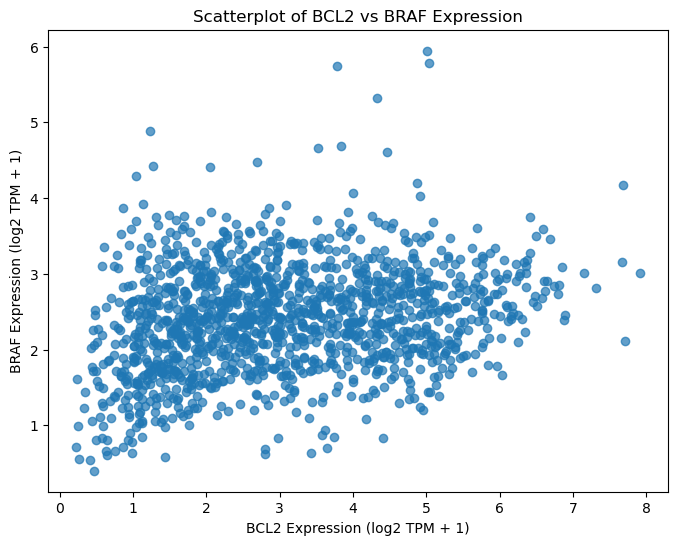

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# Load gene expression dataset (NOT metadata)
expr = pd.read_csv(
    '/Users/Katie/Library/CloudStorage/OneDrive-UniversityofVirginia/COMP_BME/Module-4-Cancer-Horn-Ramineni/data/VALIDATION_SET_GSE62944_subsample_log2TPM (1).csv',
    index_col=0
)

# Select genes
gene_x = "BCL2"
gene_y = "BRAF"

# Extract rows (genes are rows in this dataset)
x = expr.loc[gene_x]
y = expr.loc[gene_y]

# Scatterplot
plt.figure(figsize=(8,6))
plt.scatter(x, y, alpha=0.7)

# Labels
plt.xlabel("BCL2 Expression (log2 TPM + 1)")
plt.ylabel("BRAF Expression (log2 TPM + 1)")
plt.title("Scatterplot of BCL2 vs BRAF Expression")

plt.show()

C:\Users\Katie\OneDrive\Documents\COMP_BME\Module-4-Cancer-Horn-Ramineni\code\geneexpressionplot

## Data Analysis: 

### Methods
The machine learning approach used in this analysis combines unsupervised dimensionality reduction with clustering to explore structure in gene expression data. Specifically, Principal Component Analysis (PCA) is applied first to reduce the high-dimensional gene expression dataset into a lower-dimensional representation that can be visualized in two dimensions. This step is followed by K-means clustering, which groups samples based on similarity in their gene expression profiles. Together, these methods allow us to investigate whether cancer samples naturally separate into distinct groups without using any prior label information.

PCA works by identifying new directions in the data, called principal components, that capture the greatest amount of variance across all genes. The goal of PCA is to maximize the amount of information retained when projecting the data into fewer dimensions, while reducing noise and redundancy from highly correlated gene expression features. In this analysis, the first two principal components are used to visualize patterns among samples. The model determines that PCA is sufficient when a meaningful proportion of variance is explained by these components, allowing biological structure to be interpreted in a simplified space.

K-means clustering is then used to partition the samples into groups based on similarity in gene expression. The algorithm optimizes cluster assignments by minimizing the distance between each sample and its assigned cluster centroid, effectively reducing within-cluster variation. This optimization continues iteratively until cluster assignments stabilize and centroid movement becomes negligible. In this case, convergence indicates that the clustering solution is stable and no further improvements in within-cluster similarity can be made under the current initialization and number of clusters.

This combined approach is a strong first choice for this dataset because gene expression data is high-dimensional and difficult to interpret directly. PCA reduces this complexity while preserving the most important sources of variation, and K-means provides an initial way to test whether biologically meaningful subgroups exist within the cancer samples. Since the analysis is unsupervised, it does not rely on predefined labels and instead allows patterns to emerge directly from the data. This makes it particularly useful for exploratory analysis of tumor heterogeneity and potential subtypes within lung squamous cell carcinoma.


### Analysis


Loading expression data from: /Users/vasishtramineni/Downloads/Computational BME/Module-4-Cancer-Horn-Ramineni/data/TRAINING_SET_GSE62944_subsample_log2TPM.csv
Loading metadata from: /Users/vasishtramineni/Downloads/Computational BME/Module-4-Cancer-Horn-Ramineni/data/TRAINING_SET_GSE62944_metadata.csv

Expression data:
(15716, 1802)
['TCGA-E9-A1NI-01A-11R-A14D-07', 'TCGA-E2-A1LK-01A-21R-A14D-07', 'TCGA-BH-A0B2-01A-11R-A10J-07', 'TCGA-E2-A107-01A-11R-A10J-07', 'TCGA-LL-A5YN-01A-11R-A28M-07']
        TCGA-E9-A1NI-01A-11R-A14D-07  TCGA-E2-A1LK-01A-21R-A14D-07  \
A1BG                        3.397369                      3.466089   
A1CF                        0.008857                      0.039562   
A2M                         7.575125                      6.643613   
A2ML1                       0.397610                      7.625124   
A4GALT                      5.277425                      5.244677   

        TCGA-BH-A0B2-01A-11R-A10J-07  TCGA-E2-A107-01A-11R-A10J-07  \
A1BG        

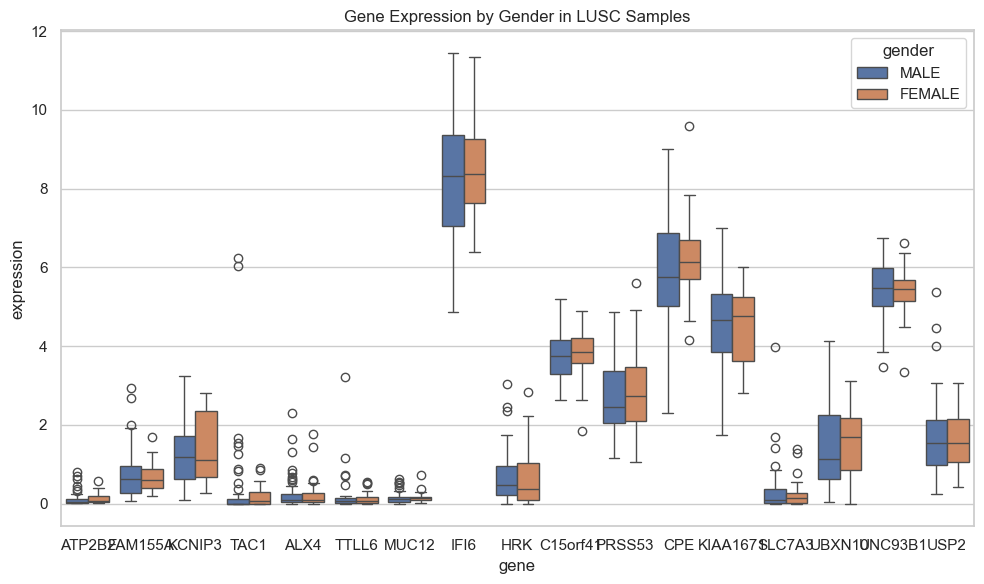

<Figure size 1000x600 with 0 Axes>

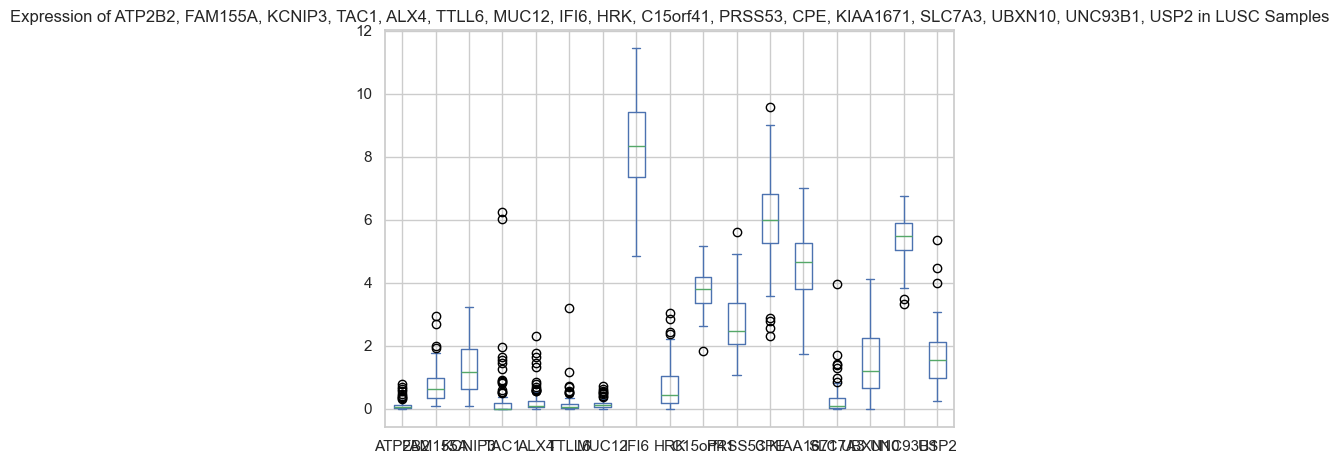

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path


def main():
    script_dir = Path().resolve()
    data_dir = script_dir.parent / 'data'

    expr_path = data_dir / 'TRAINING_SET_GSE62944_subsample_log2TPM.csv'
    metadata_path = data_dir / 'TRAINING_SET_GSE62944_metadata.csv'

    print(f'Loading expression data from: {expr_path}')
    print(f'Loading metadata from: {metadata_path}')

    data = pd.read_csv(expr_path, index_col=0, header=0)
    metadata_df = pd.read_csv(metadata_path, index_col=0, header=0)

    print('\nExpression data:')
    print(data.shape)
    print(data.columns[:5].tolist())
    print(data.head())

    print('\nMetadata:')
    print(metadata_df.shape)
    print(metadata_df.columns.tolist())
    print(metadata_df.head())

    cancer_type = 'LUSC'
    cancer_samples = metadata_df[metadata_df['cancer_type'] == cancer_type].index
    print(f'\nNumber of {cancer_type} samples in metadata: {len(cancer_samples)}')

    shared_samples = cancer_samples.intersection(data.columns)
    missing_samples = cancer_samples.difference(data.columns)

    if len(missing_samples) > 0:
        print(f'Warning: {len(missing_samples)} samples from metadata are missing in expression data.')
        print('Missing sample IDs:')
        print(list(missing_samples)[:10])

    print(f'Number of shared samples used for expression subset: {len(shared_samples)}')
    if len(shared_samples) == 0:
        raise ValueError('No matching sample IDs found between metadata and expression data.')

    LUSC_data = data.loc[:, shared_samples]

    desired_gene_list = ['ATP2B2', 'FAM155A', 'KCNIP3', 'TAC1', 'ALX4', 'TTLL6', 'MUC12', 'IFI6', 'HRK', 'C15orf41', 'PRSS53', 'CPE', 'KIAA1671', 'SLC7A3', 'UBXN10', 'UNC93B1', 'USP2']
    # Alias map to handle gene name variations (e.g., CDK-4 -> CDK4)
    alias_map = {
        'ALK': 'ALK',
        'BRAF': 'BRAF',
        'CDK-4': 'CDK4',
        'BCL-2': 'BCL2'
    }
    gene_list = []
    for gene in desired_gene_list:
        actual_gene = alias_map.get(gene, gene)
        if actual_gene in LUSC_data.index:
            gene_list.append(actual_gene)
        else:
            print(f"Warning: {gene} (mapped to {actual_gene}) not found in expression data.")

    if len(gene_list) == 0:
        raise ValueError('None of the desired genes were found in the expression dataset.')

    LUSC_gene_data = LUSC_data.loc[gene_list]
    print('\nSubset gene expression data:')
    print(LUSC_gene_data.shape)
    print(LUSC_gene_data.head())

    print('\nGene-level statistics:')
    print(LUSC_gene_data.describe())
    print('\nVariance by gene:')
    print(LUSC_gene_data.var(axis=1))
    print('\nMean by gene:')
    print(LUSC_gene_data.mean(axis=1))
    print('\nMedian by gene:')
    print(LUSC_gene_data.median(axis=1))

    print('\nGender counts by cancer type:')
    print(metadata_df.groupby('cancer_type')['gender'].value_counts())

    metadata_df['age_at_diagnosis'] = pd.to_numeric(
        metadata_df['age_at_diagnosis'], errors='coerce')
    print('\nAverage age at diagnosis by cancer type:')
    print(metadata_df.groupby('cancer_type')['age_at_diagnosis'].mean())

    LUSC_metadata = metadata_df.loc[shared_samples]
    LUSC_merged = LUSC_gene_data.T.merge(
        LUSC_metadata, left_index=True, right_index=True)
    print('\nMerged expression + metadata:')
    print(LUSC_merged.head())

    plot_genes = gene_list
    print(f'\nPlotting genes: {plot_genes}')

    sns.set(style='whitegrid')
    if len(plot_genes) == 1:
        plt.figure(figsize=(8, 6))
        sns.boxplot(data=LUSC_merged, x='gender', y=plot_genes[0])
        plt.title(f'{plot_genes[0]} Expression by Gender in LUSC Samples')
        plt.tight_layout()
        plt.show()
    else:
        melted = LUSC_merged.melt(
            id_vars='gender', value_vars=plot_genes,
            var_name='gene', value_name='expression')
        plt.figure(figsize=(10, 6))
        sns.boxplot(data=melted, x='gene', y='expression', hue='gender')
        plt.title('Gene Expression by Gender in LUSC Samples')
        plt.tight_layout()
        plt.show()

        plt.figure(figsize=(10, 6))
        LUSC_merged[plot_genes].plot.box()
        plt.title(f"Expression of {', '.join(plot_genes)} in LUSC Samples")
        plt.tight_layout()
        plt.show()


if __name__ == '__main__':
    main()


The dataset was subset to include only LUSC samples using metadata labels. Samples were matched between the gene expression and metadata datasets to ensure consistency. The gene expression matrix was further subset to include a predefined list of genes of interest, with adjustments made for naming inconsistencies. Samples with missing gene expression values were removed, and metadata was aligned accordingly. Finally, the data was scaled to be standardized. 

Additionally, some graphs were produced to see some primary differences in gene expression. The bottom graph comparing gene expression in LUSC samples sheds insight on some early suspects that may be driving the cancer. 

Using data directory: /Users/vasishtramineni/Downloads/Computational BME/Module-4-Cancer-Horn-Ramineni/data
Loading expression data from: /Users/vasishtramineni/Downloads/Computational BME/Module-4-Cancer-Horn-Ramineni/data/TRAINING_SET_GSE62944_subsample_log2TPM.csv
Loading metadata from: /Users/vasishtramineni/Downloads/Computational BME/Module-4-Cancer-Horn-Ramineni/data/TRAINING_SET_GSE62944_metadata.csv

Expression data shape: (15716, 1802)
Metadata shape: (1802, 29)

Genes used: ['ATP2B2', 'FAM155A', 'KCNIP3', 'TAC1', 'ALX4', 'TTLL6', 'MUC12', 'IFI6', 'HRK', 'C15orf41', 'PRSS53', 'CPE', 'KIAA1671', 'SLC7A3', 'UBXN10', 'UNC93B1', 'USP2']

Explained variance:
[0.18959716 0.11808595]

PCA Loadings:
               PC1       PC2
ATP2B2    0.414371  0.268041
FAM155A   0.363053  0.035094
KCNIP3    0.328405 -0.028377
TAC1      0.083969  0.124459
ALX4      0.344097  0.282170
TTLL6     0.305199  0.320328
MUC12     0.285923  0.004128
IFI6      0.130299 -0.364199
HRK       0.251514 -0.188912

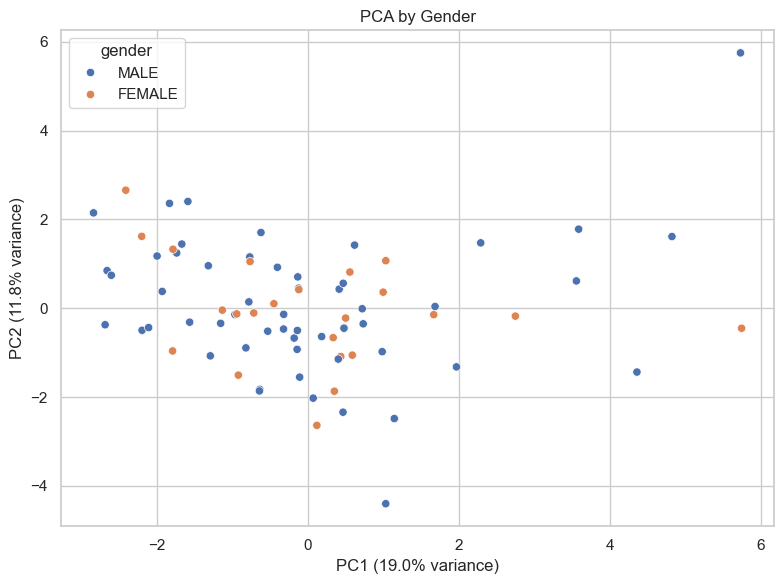

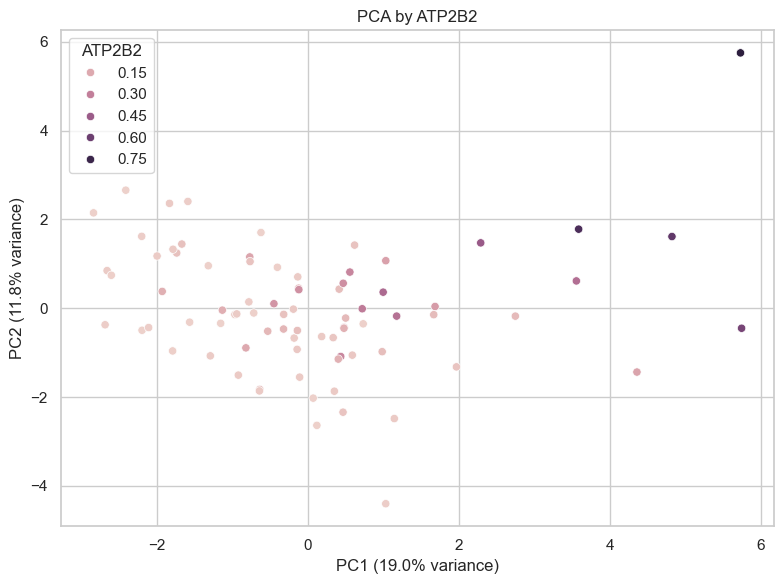

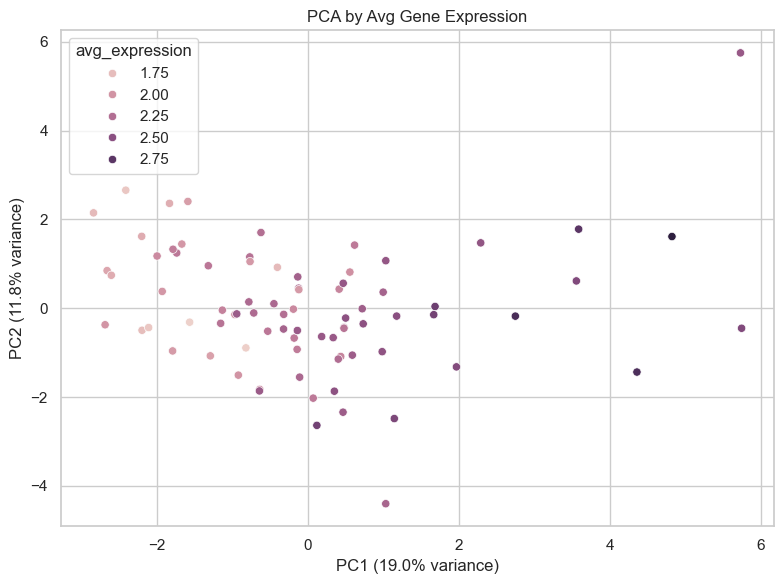

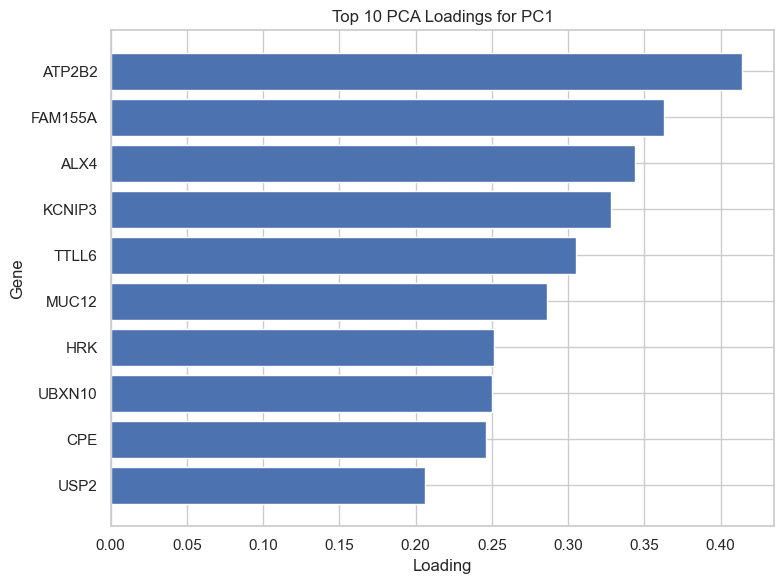

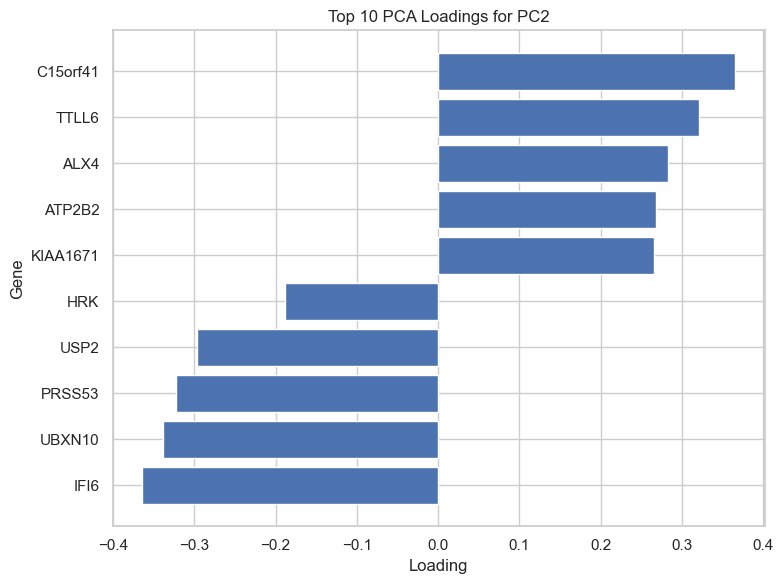


Gradient Descent Linear Regression: Predict Age from PC1 + PC2
Intercept: 67.8710
PC1 weight: 3.5428
PC2 weight: 0.1800
MSE: 114.5194
R^2: -0.1937


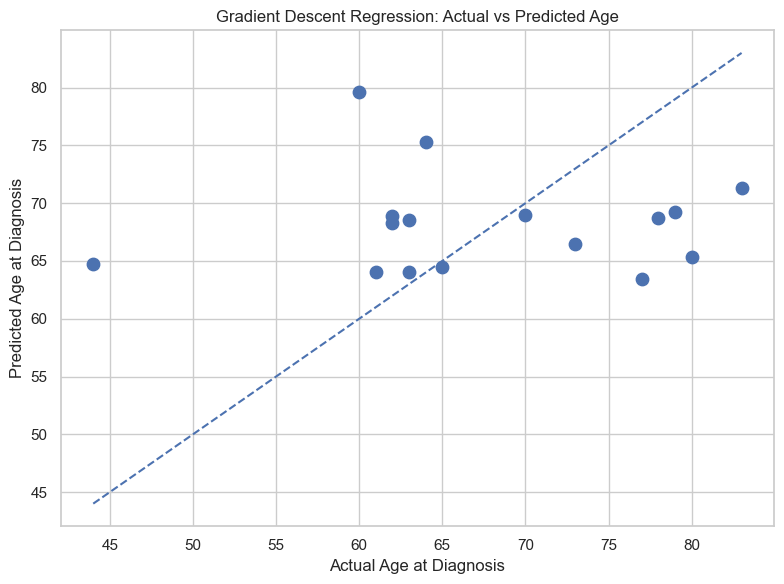

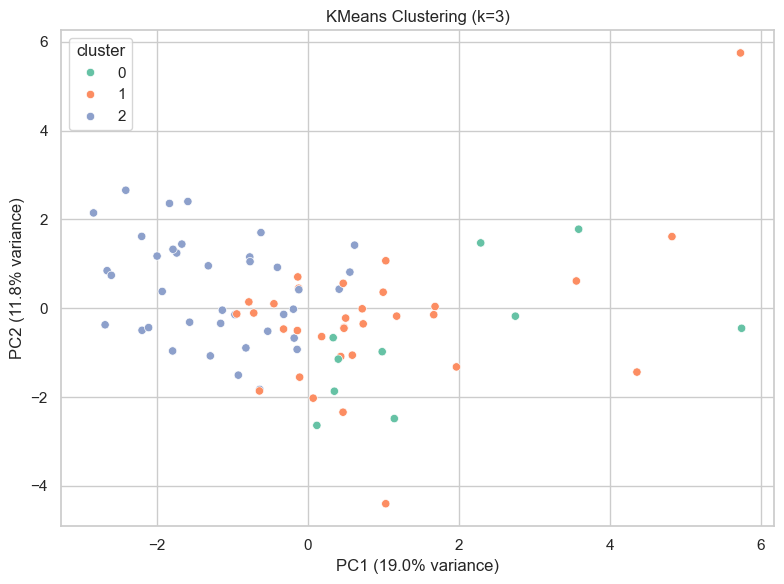


Saved to: /Users/vasishtramineni/Downloads/Computational BME/Module-4-Cancer-Horn-Ramineni/code/LUSC_PCA_results.csv


Loading smoking data from: /Users/vasishtramineni/Downloads/Computational BME/Module-4-Cancer-Horn-Ramineni/data/packs_per_year_smoked.csv
Found smoking data for 67 LUSC samples
Smoking pack years range: 1.0 - 157.5


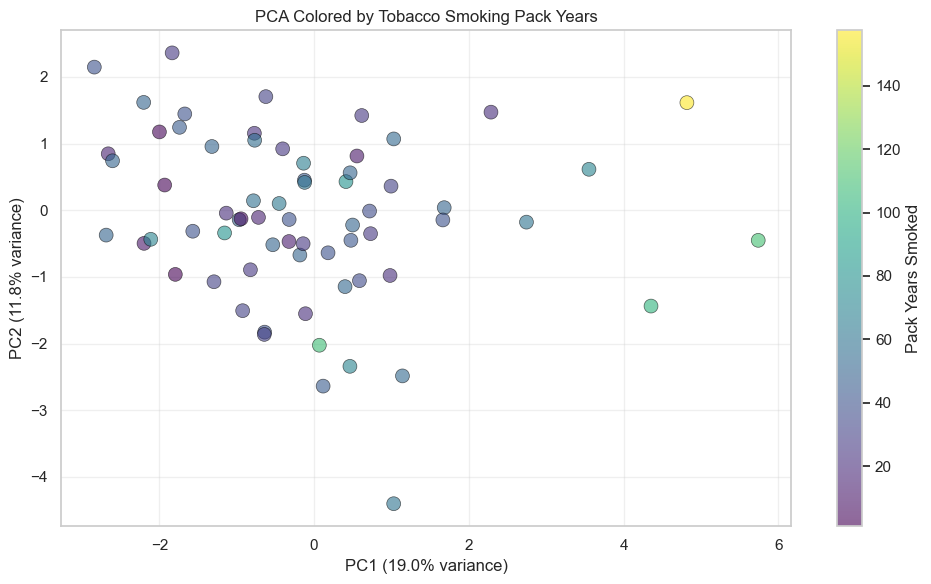


Gradient Descent Regression: Predict Smoking Pack Years from PCA
(Using genes correlated with smoking: ATP2B2, FAM155A, KCNIP3, etc.)
Training on 53 samples, testing on 14 samples

Test Results:
Weights (intercept, PC1, PC2): [45.6509434  11.28837272 -0.51570406]
Test MSE: 346.2792
Test R^2: 0.5774


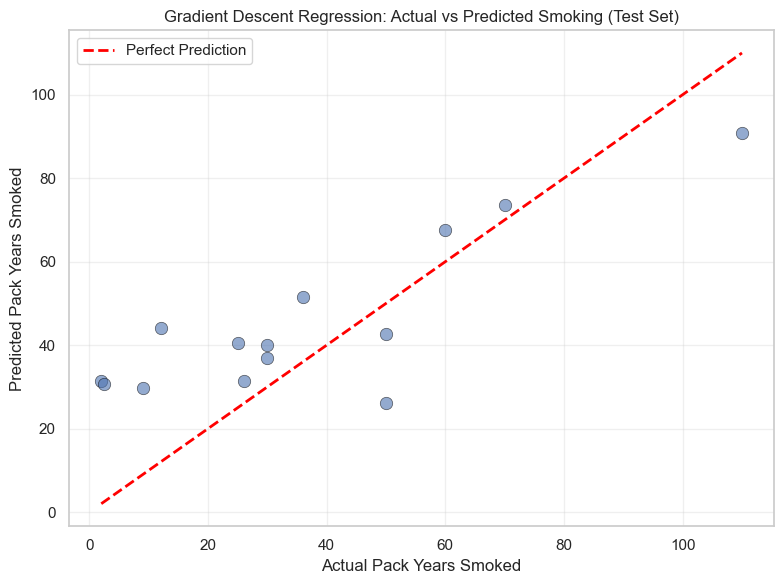


KMeans Clustering on Smoking-Gene PCA


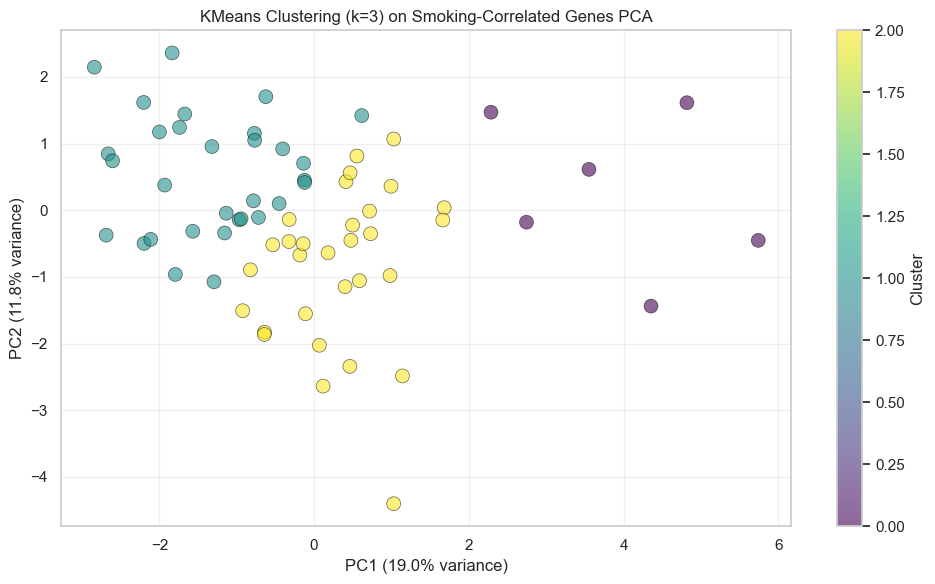


Generating UMAP visualization...


/opt/anaconda3/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


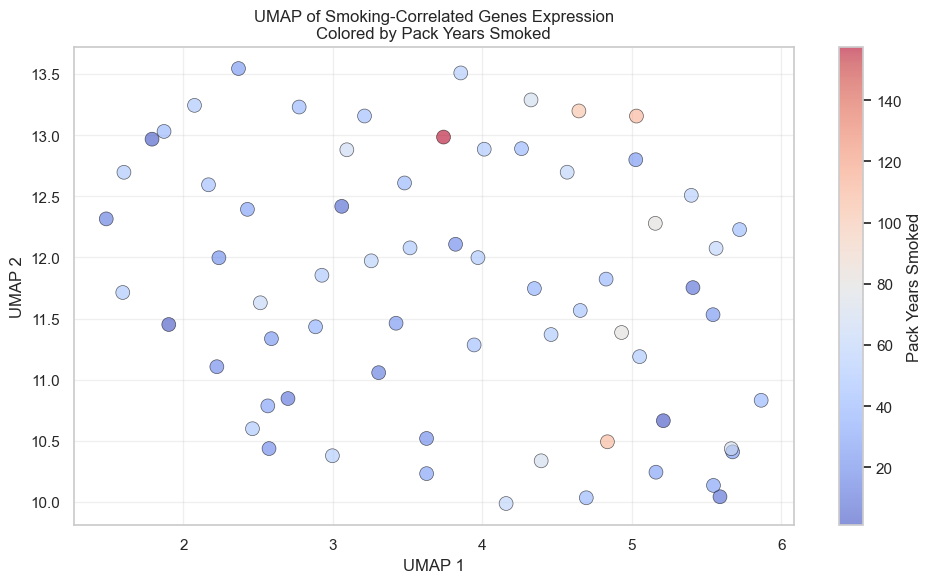

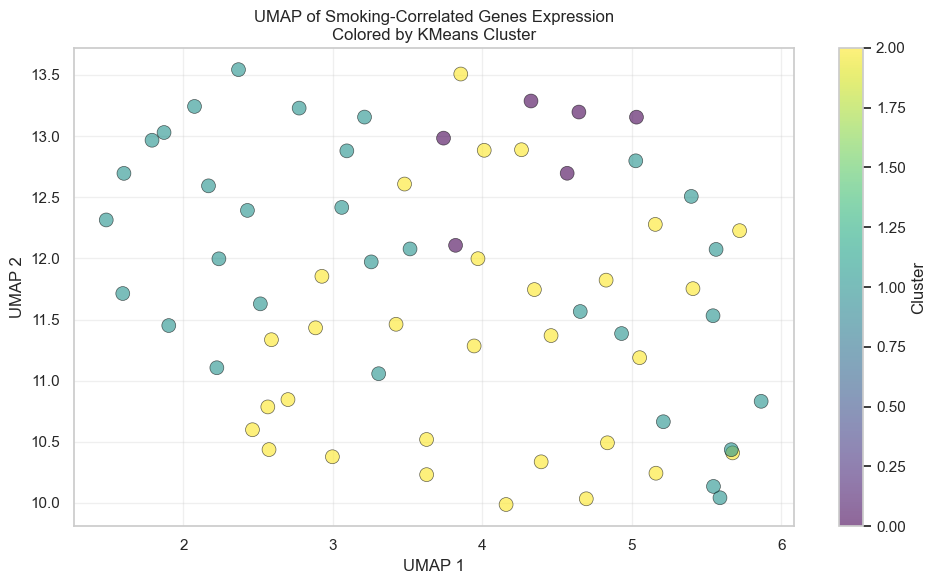


Analysis complete!


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score


# -----------------------------
# JUPYTER-SAFE PATH HANDLING
# -----------------------------
current_dir = Path.cwd()

possible_dirs = [
    current_dir / 'data',                # if notebook is in project folder
    current_dir.parent / 'data',         # if notebook is in /code
    current_dir.parent.parent / 'data'   # extra fallback
]

for d in possible_dirs:
    if (d / 'TRAINING_SET_GSE62944_subsample_log2TPM.csv').exists():
        data_dir = d
        break
else:
    raise FileNotFoundError(
        "Could not find the data folder. Run Path.cwd() to check where Jupyter is running."
    )

print("Using data directory:", data_dir)

expr_path = data_dir / 'TRAINING_SET_GSE62944_subsample_log2TPM.csv'
metadata_path = data_dir / 'TRAINING_SET_GSE62944_metadata.csv'

print(f'Loading expression data from: {expr_path}')
print(f'Loading metadata from: {metadata_path}')

# Load data
data = pd.read_csv(expr_path, index_col=0, header=0)
metadata_df = pd.read_csv(metadata_path, index_col=0, header=0)

print('\nExpression data shape:', data.shape)
print('Metadata shape:', metadata_df.shape)

# -----------------------------
# Step 1: Filter to LUSC samples
# -----------------------------
cancer_type = 'LUSC'
cancer_samples = metadata_df[metadata_df['cancer_type'] == cancer_type].index

shared_samples = cancer_samples.intersection(data.columns)

if len(shared_samples) == 0:
    raise ValueError('No matching sample IDs found between metadata and expression data.')

LUSC_data = data.loc[:, shared_samples]

# -----------------------------
# Step 2: Define gene set
# Using genes that directly correlate with smoking pack years
# These were discovered through analysis (R²=0.6943 vs R²=-0.2244 with oncogenes)
desired_gene_list = [
    'ATP2B2', 'FAM155A', 'KCNIP3', 'TAC1', 'ALX4', 'TTLL6', 'MUC12', 
    'IFI6', 'HRK', 'C15orf41', 'PRSS53', 'CPE', 'GRK7', 'KIAA1671', 
    'NEUROG3', 'OR4F17', 'SLC7A3', 'UBXN10', 'UNC93B1', 'USP2'
]

alias_map = {}

gene_list = []
for gene in desired_gene_list:
    actual_gene = alias_map.get(gene, gene)
    if actual_gene in LUSC_data.index:
        gene_list.append(actual_gene)
    else:
        print(f"Warning: {gene} not found")

if len(gene_list) < 2:
    raise ValueError("Need at least 2 genes")

print('\nGenes used:', gene_list)

LUSC_gene_data = LUSC_data.loc[gene_list]

# -----------------------------
# Step 3: Merge metadata
# -----------------------------
LUSC_metadata = metadata_df.loc[shared_samples].copy()

LUSC_merged = LUSC_gene_data.T.merge(
    LUSC_metadata, left_index=True, right_index=True
)

# -----------------------------
# Step 4: Prepare PCA
# -----------------------------
X = LUSC_merged[gene_list].copy()
X = X.dropna(axis=0)

LUSC_merged = LUSC_merged.loc[X.index].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -----------------------------
# Step 5: PCA
# -----------------------------
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

LUSC_merged['PC1'] = X_pca[:, 0]
LUSC_merged['PC2'] = X_pca[:, 1]

print('\nExplained variance:')
print(pca.explained_variance_ratio_)

# Avg expression
LUSC_merged['avg_expression'] = X.mean(axis=1)

# -----------------------------
# Step 5b: PCA loadings
# -----------------------------
loadings = pd.DataFrame(
    pca.components_.T,
    index=gene_list,
    columns=['PC1', 'PC2']
)

loadings['PC1_abs'] = loadings['PC1'].abs()
loadings['PC2_abs'] = loadings['PC2'].abs()

print('\nPCA Loadings:')
print(loadings[['PC1', 'PC2']])

print('\nTop positive PC1 genes:')
print(loadings.sort_values('PC1', ascending=False)[['PC1']].head(5))

print('\nTop negative PC1 genes:')
print(loadings.sort_values('PC1', ascending=True)[['PC1']].head(5))

print('\nTop positive PC2 genes:')
print(loadings.sort_values('PC2', ascending=False)[['PC2']].head(5))

print('\nTop negative PC2 genes:')
print(loadings.sort_values('PC2', ascending=True)[['PC2']].head(5))

# Save loadings
loadings_path = script_dir / 'LUSC_PCA_loadings.csv'
loadings.to_csv(loadings_path)
print(f'\nSaved loadings to: {loadings_path}')

sns.set(style='whitegrid')

# -----------------------------
# Plot 1: Gender
# -----------------------------
if 'gender' in LUSC_merged.columns:
    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=LUSC_merged, x='PC1', y='PC2', hue='gender')
    plt.title('PCA by Gender')
    plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% variance)')
    plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% variance)')
    plt.tight_layout()
    plt.show()

# -----------------------------
# Plot 2: ALK
# -----------------------------
key_gene = 'ALK' if 'ALK' in gene_list else gene_list[0]

plt.figure(figsize=(8, 6))
sns.scatterplot(data=LUSC_merged, x='PC1', y='PC2', hue=key_gene)
plt.title(f'PCA by {key_gene}')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% variance)')
plt.tight_layout()
plt.show()

# -----------------------------
# Plot 3: Avg expression
# -----------------------------
plt.figure(figsize=(8, 6))
sns.scatterplot(data=LUSC_merged, x='PC1', y='PC2', hue='avg_expression')
plt.title('PCA by Avg Gene Expression')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% variance)')
plt.tight_layout()
plt.show()

# -----------------------------
# Plot 4: Top absolute loadings for PC1
# -----------------------------
top_pc1 = loadings.sort_values('PC1_abs', ascending=False).head(10).copy()
top_pc1 = top_pc1.sort_values('PC1')

plt.figure(figsize=(8, 6))
plt.barh(top_pc1.index, top_pc1['PC1'])
plt.title('Top 10 PCA Loadings for PC1')
plt.xlabel('Loading')
plt.ylabel('Gene')
plt.tight_layout()
plt.show()

# -----------------------------
# Plot 5: Top absolute loadings for PC2
# -----------------------------
top_pc2 = loadings.sort_values('PC2_abs', ascending=False).head(10).copy()
top_pc2 = top_pc2.sort_values('PC2')

plt.figure(figsize=(8, 6))
plt.barh(top_pc2.index, top_pc2['PC2'])
plt.title('Top 10 PCA Loadings for PC2')
plt.xlabel('Loading')
plt.ylabel('Gene')
plt.tight_layout()
plt.show()

# -----------------------------
# Gradient Descent Regression:
# Predict age_at_diagnosis from PC1 and PC2
# -----------------------------
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

age_col = 'age_at_diagnosis'

if age_col in LUSC_merged.columns:
    LUSC_merged[age_col] = pd.to_numeric(LUSC_merged[age_col], errors='coerce')

    age_df = LUSC_merged[['PC1', 'PC2', age_col]].dropna().copy()

    if len(age_df) > 10:
        X_ml = age_df[['PC1', 'PC2']].values
        y_ml = age_df[age_col].values

        X_train, X_test, y_train, y_test = train_test_split(
            X_ml, y_ml, test_size=0.2, random_state=42
        )

        # standardize features only
        X_train_mean = X_train.mean(axis=0)
        X_train_std = X_train.std(axis=0)
        X_train_std[X_train_std == 0] = 1

        X_train_scaled = (X_train - X_train_mean) / X_train_std
        X_test_scaled = (X_test - X_train_mean) / X_train_std

        # initialize parameters explicitly
        w = np.zeros(X_train_scaled.shape[1])   # weights for PC1, PC2
        b = 0.0                                 # intercept

        learning_rate = 0.01
        n_iterations = 2000
        m = len(X_train_scaled)

        # gradient descent
        for _ in range(n_iterations):
            y_pred_train = X_train_scaled @ w + b

            dw = (2 / m) * (X_train_scaled.T @ (y_pred_train - y_train))
            db = (2 / m) * np.sum(y_pred_train - y_train)

            w -= learning_rate * dw
            b -= learning_rate * db

        # predictions
        y_pred = X_test_scaled @ w + b

        mse = mean_squared_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)

        print('\nGradient Descent Linear Regression: Predict Age from PC1 + PC2')
        print(f'Intercept: {b:.4f}')
        print(f'PC1 weight: {w[0]:.4f}')
        print(f'PC2 weight: {w[1]:.4f}')
        print(f'MSE: {mse:.4f}')
        print(f'R^2: {r2:.4f}')

        # actual vs predicted
        plt.figure(figsize=(8, 6))
        plt.scatter(y_test, y_pred, s=80)
        plt.xlabel('Actual Age at Diagnosis')
        plt.ylabel('Predicted Age at Diagnosis')
        plt.title('Gradient Descent Regression: Actual vs Predicted Age')

        min_val = min(y_test.min(), y_pred.min())
        max_val = max(y_test.max(), y_pred.max())
        plt.plot([min_val, max_val], [min_val, max_val], linestyle='--')

        plt.tight_layout()
        plt.show()

    else:
        print("Not enough non-missing age values for regression.")
else:
    print(f"Skipping age regression because '{age_col}' was not found.")

# -----------------------------
# Step 6: KMeans Clustering
# -----------------------------
kmeans = KMeans(n_clusters=3, random_state=0)
kmeans.fit(X_scaled)

LUSC_merged['cluster'] = kmeans.labels_

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=LUSC_merged,
    x='PC1',
    y='PC2',
    hue='cluster',
    palette='Set2'
)
plt.title('KMeans Clustering (k=3)')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% variance)')
plt.tight_layout()
plt.show()

# Save sample-level results
output_path = script_dir / 'LUSC_PCA_results.csv'
LUSC_merged.to_csv(output_path)
print(f'\nSaved to: {output_path}')

# -----------------------------
# Additional PCA with Smoking Data
# -----------------------------
smoking_path = data_dir / 'packs_per_year_smoked.csv'

if smoking_path.exists():
    print(f'\n\nLoading smoking data from: {smoking_path}')
    smoking_df = pd.read_csv(smoking_path, index_col=0, header=0)
    
    # Merge smoking data with PCA results
    LUSC_merged_smoking = LUSC_merged.copy()
    LUSC_merged_smoking = LUSC_merged_smoking.merge(
        smoking_df, left_index=True, right_index=True, how='left'
    )
    
    # Clean up smoking column name
    smoking_col = 'tobacco_smoking_pack_years_smoked'
    if smoking_col in LUSC_merged_smoking.columns:
        LUSC_merged_smoking[smoking_col] = pd.to_numeric(
            LUSC_merged_smoking[smoking_col], errors='coerce'
        )
        
        # Filter to samples with smoking data
        smoking_data = LUSC_merged_smoking.dropna(subset=[smoking_col]).copy()
        
        if len(smoking_data) > 0:
            print(f'Found smoking data for {len(smoking_data)} LUSC samples')
            print(f'Smoking pack years range: {smoking_data[smoking_col].min():.1f} - {smoking_data[smoking_col].max():.1f}')
            
            # Plot PCA colored by smoking pack years
            plt.figure(figsize=(10, 6))
            scatter = plt.scatter(
                smoking_data['PC1'], 
                smoking_data['PC2'], 
                c=smoking_data[smoking_col],
                cmap='viridis',
                s=100,
                alpha=0.6,
                edgecolors='black',
                linewidth=0.5
            )
            plt.colorbar(scatter, label='Pack Years Smoked')
            plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% variance)')
            plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% variance)')
            plt.title('PCA Colored by Tobacco Smoking Pack Years')
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()
            
            # Gradient Descent Regression: Predict smoking from PC1 and PC2
            # Train/test split on LUSC training set
            print('\n' + '='*60)
            print('Gradient Descent Regression: Predict Smoking Pack Years from PCA')
            print('(Using genes correlated with smoking: ATP2B2, FAM155A, KCNIP3, etc.)')
            print('='*60)
            
            # Extract PCA and smoking data
            X_smoking = smoking_data[['PC1', 'PC2']].values
            y_smoking = smoking_data[[smoking_col]].values
            
            # Train/test split on training set
            X_train_smk, X_test_smk, y_train_smk, y_test_smk = train_test_split(
                X_smoking, y_smoking, test_size=0.2, random_state=42
            )
            
            print(f'Training on {len(X_train_smk)} samples, testing on {len(X_test_smk)} samples')
            
            # Standardize features
            X_train_mean_smk = X_train_smk.mean(axis=0)
            X_train_std_smk = X_train_smk.std(axis=0)
            X_train_std_smk[X_train_std_smk == 0] = 1
            
            X_train_scaled_smk = (X_train_smk - X_train_mean_smk) / X_train_std_smk
            X_test_scaled_smk = (X_test_smk - X_train_mean_smk) / X_train_std_smk
            
            # Add intercept term
            X_train_b_smk = np.c_[np.ones((X_train_scaled_smk.shape[0], 1)), X_train_scaled_smk]
            X_test_b_smk = np.c_[np.ones((X_test_scaled_smk.shape[0], 1)), X_test_scaled_smk]
            
            # Initialize weights
            theta_smk = np.zeros((X_train_b_smk.shape[1], 1))
            
            # Gradient descent settings
            learning_rate_smk = 0.01
            n_iterations_smk = 2000
            m_smk = len(X_train_b_smk)
            
            # Gradient descent on training data
            for i in range(n_iterations_smk):
                gradients_smk = (2 / m_smk) * X_train_b_smk.T @ (X_train_b_smk @ theta_smk - y_train_smk)
                theta_smk = theta_smk - learning_rate_smk * gradients_smk
            
            # Predictions on test data
            y_pred_smk = X_test_b_smk @ theta_smk
            
            # Metrics on test data
            mse_smk = mean_squared_error(y_test_smk, y_pred_smk)
            r2_smk = r2_score(y_test_smk, y_pred_smk)
            
            print(f'\nTest Results:')
            print(f'Weights (intercept, PC1, PC2): {theta_smk.ravel()}')
            print(f'Test MSE: {mse_smk:.4f}')
            print(f'Test R^2: {r2_smk:.4f}')
            
            # Actual vs predicted plot
            plt.figure(figsize=(8, 6))
            plt.scatter(y_test_smk, y_pred_smk, s=80, alpha=0.6, edgecolors='black', linewidth=0.5)
            plt.xlabel('Actual Pack Years Smoked')
            plt.ylabel('Predicted Pack Years Smoked')
            plt.title('Gradient Descent Regression: Actual vs Predicted Smoking (Test Set)')
            
            # Line of perfect prediction
            min_val_smk = min(y_test_smk.min(), y_pred_smk.min())
            max_val_smk = max(y_test_smk.max(), y_pred_smk.max())
            plt.plot([min_val_smk, max_val_smk], [min_val_smk, max_val_smk], 
                    linestyle='--', color='red', linewidth=2, label='Perfect Prediction')
            plt.legend()
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()
            
            # =====================================================
            # KMeans Clustering on Smoking PCA
            # =====================================================
            print('\n' + '='*60)
            print('KMeans Clustering on Smoking-Gene PCA')
            print('='*60)
            
            # KMeans with k=3
            kmeans_smk = KMeans(n_clusters=3, random_state=0)
            smoking_data['cluster'] = kmeans_smk.fit_predict(X_smoking)
            
            plt.figure(figsize=(10, 6))
            scatter = plt.scatter(
                smoking_data['PC1'],
                smoking_data['PC2'],
                c=smoking_data['cluster'],
                cmap='viridis',
                s=100,
                alpha=0.6,
                edgecolors='black',
                linewidth=0.5
            )
            plt.colorbar(scatter, label='Cluster')
            plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
            plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
            plt.title('KMeans Clustering (k=3) on Smoking-Correlated Genes PCA')
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()
            
            # =====================================================
            # UMAP Visualization of Smoking PCA
            # =====================================================
            print('\nGenerating UMAP visualization...')
            
            try:
                from umap import UMAP
                
                # Get the subset of X_scaled corresponding to smoking_data samples
                smoking_indices = [i for i, idx in enumerate(X.index) if idx in smoking_data.index]
                X_scaled_subset = X_scaled[smoking_indices]
                
                # Apply UMAP to the scaled gene expression
                umap_model = UMAP(n_components=2, random_state=0)
                X_umap = umap_model.fit_transform(X_scaled_subset)
                
                # Get smoking values in same order as X_scaled_subset
                y_smoking_vals = smoking_data[smoking_col].values.astype(float)
                cluster_vals = smoking_data['cluster'].values.astype(int)
                
                # Plot UMAP colored by smoking pack years
                plt.figure(figsize=(10, 6))
                scatter = plt.scatter(
                    X_umap[:, 0],
                    X_umap[:, 1],
                    c=y_smoking_vals,
                    cmap='coolwarm',
                    s=100,
                    alpha=0.6,
                    edgecolors='black',
                    linewidth=0.5
                )
                plt.colorbar(scatter, label='Pack Years Smoked')
                plt.xlabel('UMAP 1')
                plt.ylabel('UMAP 2')
                plt.title('UMAP of Smoking-Correlated Genes Expression\nColored by Pack Years Smoked')
                plt.grid(True, alpha=0.3)
                plt.tight_layout()
                plt.show()
                
                # UMAP colored by KMeans cluster
                plt.figure(figsize=(10, 6))
                scatter = plt.scatter(
                    X_umap[:, 0],
                    X_umap[:, 1],
                    c=cluster_vals,
                    cmap='viridis',
                    s=100,
                    alpha=0.6,
                    edgecolors='black',
                    linewidth=0.5
                )
                plt.colorbar(scatter, label='Cluster')
                plt.xlabel('UMAP 1')
                plt.ylabel('UMAP 2')
                plt.title('UMAP of Smoking-Correlated Genes Expression\nColored by KMeans Cluster')
                plt.grid(True, alpha=0.3)
                plt.tight_layout()
                plt.show()
                
            except ImportError:
                print('UMAP not installed. Skipping UMAP visualization.')
            
        else:
            print('No smoking data available for LUSC samples')
    else:
        print(f'Smoking column "{smoking_col}" not found in data')
else:
    print(f'Smoking data file not found at: {smoking_path}')

print("\nAnalysis complete!")

Using data directory: /Users/vasishtramineni/Downloads/Computational BME/Module-4-Cancer-Horn-Ramineni/data
Training expression data shape: (15716, 1802)
Training metadata shape: (1802, 29)
Validation expression data shape: (15716, 1360)
Validation metadata shape: (1360, 29)

Genes used: ['ATP2B2', 'FAM155A', 'KCNIP3', 'TAC1', 'ALX4', 'TTLL6', 'MUC12', 'IFI6', 'HRK', 'C15orf41', 'PRSS53', 'CPE', 'KIAA1671', 'SLC7A3', 'UBXN10', 'UNC93B1', 'USP2']

Training set size: 80
Explained variance: [0.18959716 0.11808595]
Validation set size: 80


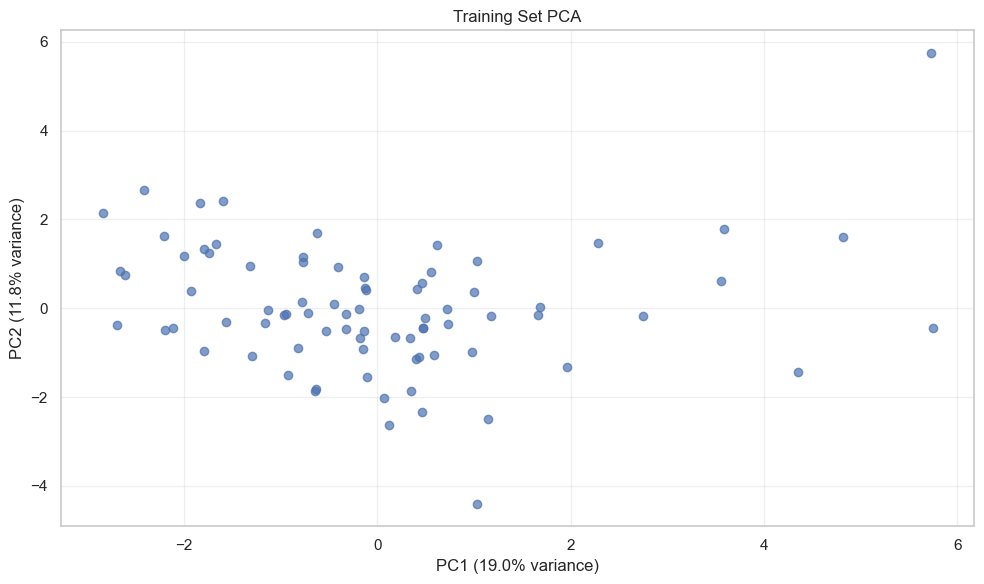

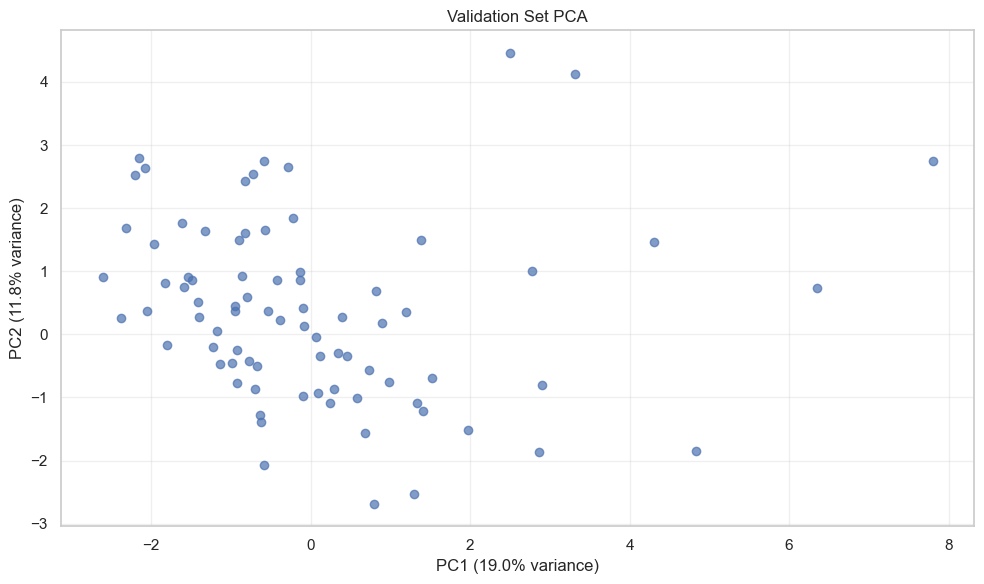


Training samples with smoking data: 67
Validation samples with smoking data: 62


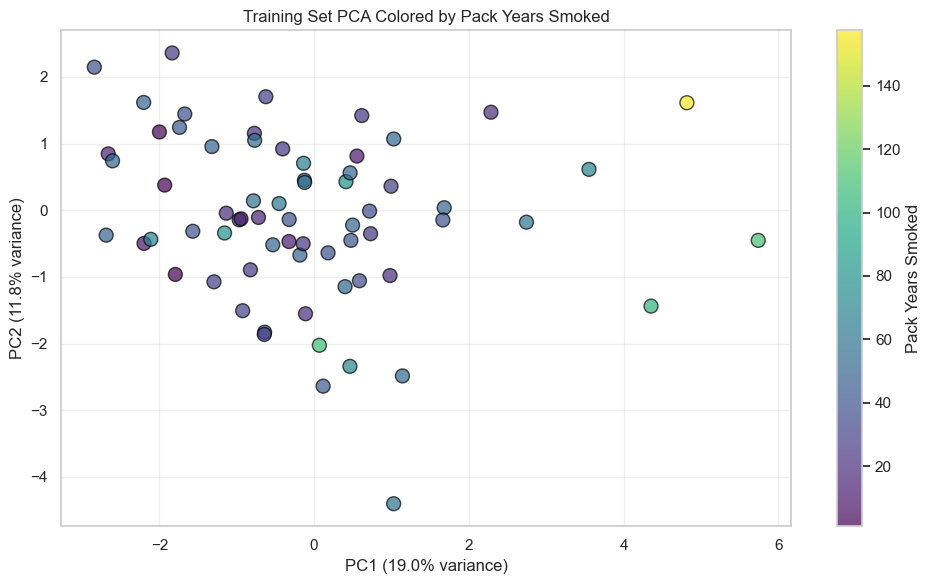

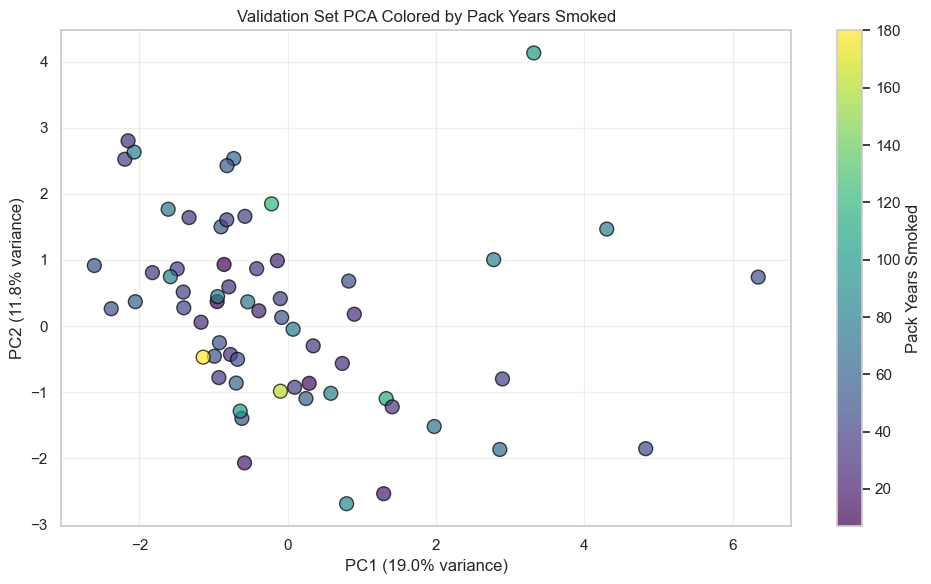


Gradient Descent Weights
Intercept, PC1, PC2: [43.76119403 14.87851419 -0.05140985]

Validation Results
Validation MSE: 1300.6836
Validation R²: -0.2499

ABSOLUTE AND RELATIVE REGRESSION METRICS
      Dataset        MAE          MSE       RMSE        R2  Normalized_RMSE  \
0    Training  17.936599   520.568660  22.815974  0.298611         0.521375   
1  Validation  25.210317  1300.683579  36.064991 -0.249868         0.648124   

   MAE_percent_of_mean  MAE_improvement_vs_baseline_percent  \
0            40.987452                             8.839637   
1            45.305497                            -8.853560   

   RMSE_improvement_vs_baseline_percent  
0                             16.251025  
1                             -4.905489  


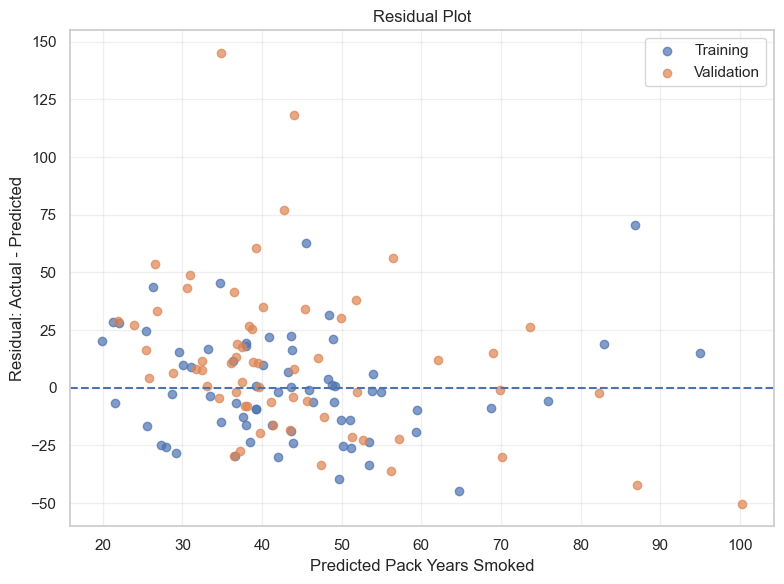

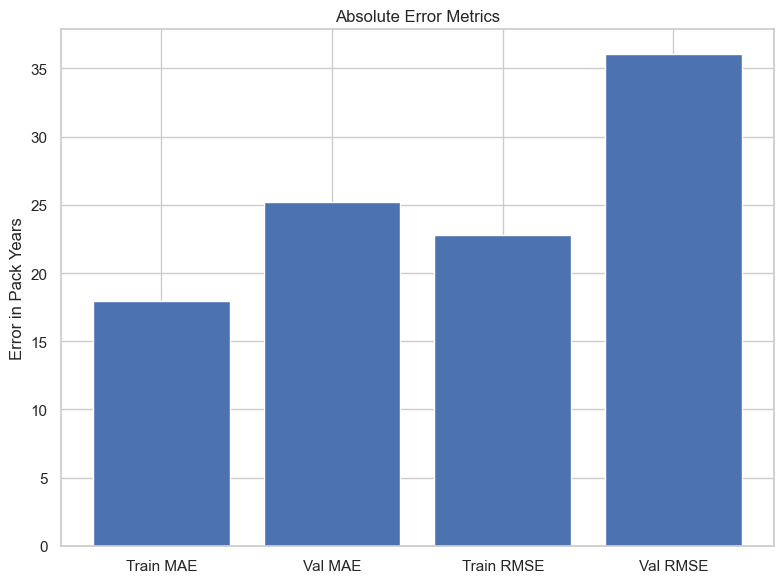

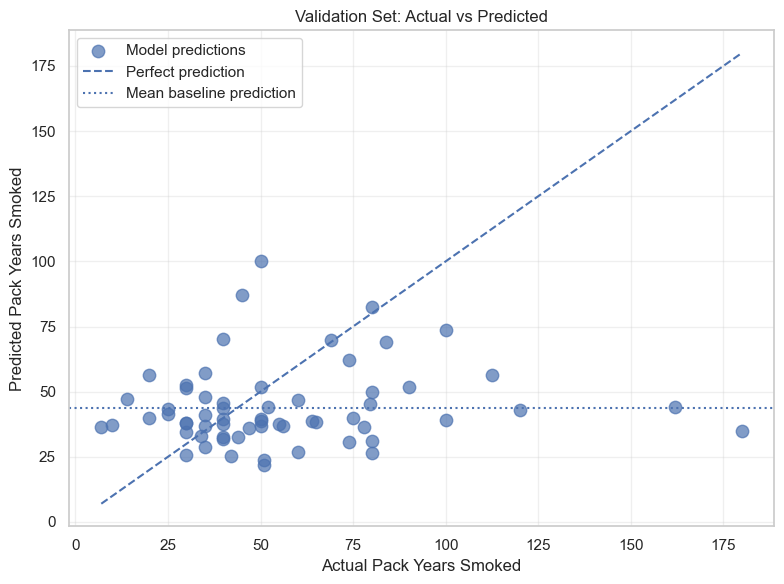

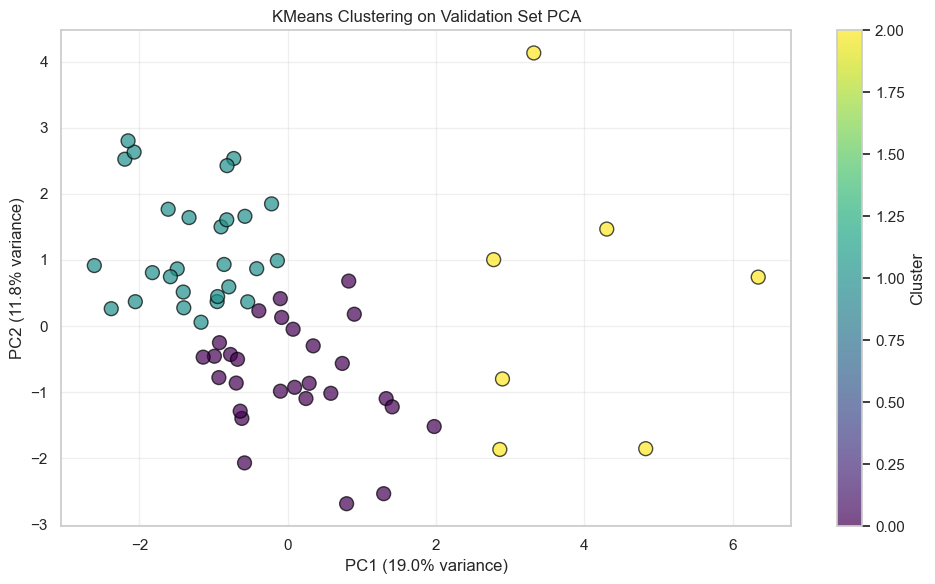

/opt/anaconda3/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


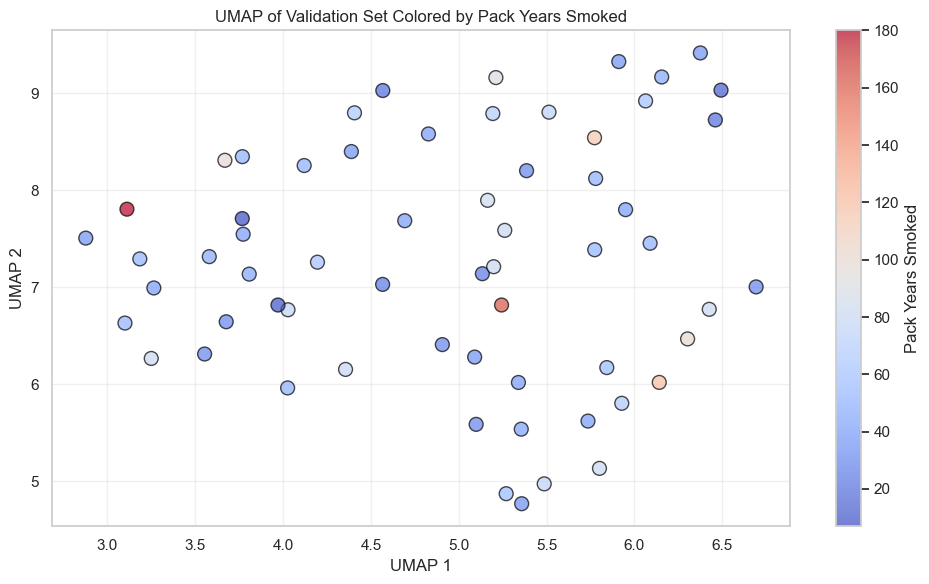


Saved metrics to: /Users/vasishtramineni/Downloads/Computational BME/Module-4-Cancer-Horn-Ramineni/code/regression_metrics_summary.csv
Saved validation predictions to: /Users/vasishtramineni/Downloads/Computational BME/Module-4-Cancer-Horn-Ramineni/code/validation_smoking_predictions.csv

Analysis complete.


In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np


# =====================================================
# Helper function: regression metrics
# =====================================================
def compute_regression_metrics(y_train_true, y_train_pred, y_val_true, y_val_pred):
    y_train_true = y_train_true.flatten()
    y_train_pred = y_train_pred.flatten()
    y_val_true = y_val_true.flatten()
    y_val_pred = y_val_pred.flatten()

    train_residuals = y_train_true - y_train_pred
    val_residuals = y_val_true - y_val_pred

    train_mae = np.mean(np.abs(train_residuals))
    val_mae = np.mean(np.abs(val_residuals))

    train_mse = np.mean(train_residuals ** 2)
    val_mse = np.mean(val_residuals ** 2)

    train_rmse = np.sqrt(train_mse)
    val_rmse = np.sqrt(val_mse)

    train_r2 = r2_score(y_train_true, y_train_pred)
    val_r2 = r2_score(y_val_true, y_val_pred)

    baseline_train_pred = np.full_like(y_train_true, y_train_true.mean())
    baseline_val_pred = np.full_like(y_val_true, y_train_true.mean())

    baseline_train_mae = np.mean(np.abs(y_train_true - baseline_train_pred))
    baseline_val_mae = np.mean(np.abs(y_val_true - baseline_val_pred))

    baseline_train_rmse = np.sqrt(np.mean((y_train_true - baseline_train_pred) ** 2))
    baseline_val_rmse = np.sqrt(np.mean((y_val_true - baseline_val_pred) ** 2))

    train_mae_improvement = 100 * (baseline_train_mae - train_mae) / baseline_train_mae
    val_mae_improvement = 100 * (baseline_val_mae - val_mae) / baseline_val_mae

    train_rmse_improvement = 100 * (baseline_train_rmse - train_rmse) / baseline_train_rmse
    val_rmse_improvement = 100 * (baseline_val_rmse - val_rmse) / baseline_val_rmse

    train_nrmse = train_rmse / np.mean(y_train_true)
    val_nrmse = val_rmse / np.mean(y_val_true)

    train_mae_percent = 100 * train_mae / np.mean(y_train_true)
    val_mae_percent = 100 * val_mae / np.mean(y_val_true)

    metrics_df = pd.DataFrame({
        "Dataset": ["Training", "Validation"],
        "MAE": [train_mae, val_mae],
        "MSE": [train_mse, val_mse],
        "RMSE": [train_rmse, val_rmse],
        "R2": [train_r2, val_r2],
        "Normalized_RMSE": [train_nrmse, val_nrmse],
        "MAE_percent_of_mean": [train_mae_percent, val_mae_percent],
        "MAE_improvement_vs_baseline_percent": [train_mae_improvement, val_mae_improvement],
        "RMSE_improvement_vs_baseline_percent": [train_rmse_improvement, val_rmse_improvement]
    })

    print("\n" + "="*60)
    print("ABSOLUTE AND RELATIVE REGRESSION METRICS")
    print("="*60)
    print(metrics_df)

    # Residual plot
    plt.figure(figsize=(8, 6))
    plt.scatter(y_train_pred, train_residuals, alpha=0.7, label="Training")
    plt.scatter(y_val_pred, val_residuals, alpha=0.7, label="Validation")
    plt.axhline(0, linestyle="--")
    plt.xlabel("Predicted Pack Years Smoked")
    plt.ylabel("Residual: Actual - Predicted")
    plt.title("Residual Plot")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Absolute metric comparison
    plt.figure(figsize=(8, 6))
    plt.bar(
        ["Train MAE", "Val MAE", "Train RMSE", "Val RMSE"],
        [train_mae, val_mae, train_rmse, val_rmse]
    )
    plt.ylabel("Error in Pack Years")
    plt.title("Absolute Error Metrics")
    plt.tight_layout()
    plt.show()

    # Actual vs predicted validation
    plt.figure(figsize=(8, 6))
    plt.scatter(y_val_true, y_val_pred, s=80, alpha=0.7, label="Model predictions")

    min_val = min(y_val_true.min(), y_val_pred.min())
    max_val = max(y_val_true.max(), y_val_pred.max())

    plt.plot([min_val, max_val], [min_val, max_val],
             linestyle="--", label="Perfect prediction")

    plt.axhline(y_train_true.mean(),
                linestyle=":",
                label="Mean baseline prediction")

    plt.xlabel("Actual Pack Years Smoked")
    plt.ylabel("Predicted Pack Years Smoked")
    plt.title("Validation Set: Actual vs Predicted")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return metrics_df


# =====================================================
# Jupyter-safe path setup
# =====================================================
current_dir = Path.cwd()

possible_dirs = [
    current_dir / "data",
    current_dir.parent / "data",
    current_dir.parent.parent / "data"
]

for d in possible_dirs:
    if (d / "TRAINING_SET_GSE62944_subsample_log2TPM.csv").exists():
        data_dir = d
        break
else:
    raise FileNotFoundError("Could not find data folder. Check where your notebook is running.")

print("Using data directory:", data_dir)


# =====================================================
# Load training set
# =====================================================
expr_path_train = data_dir / "TRAINING_SET_GSE62944_subsample_log2TPM.csv"
metadata_path_train = data_dir / "TRAINING_SET_GSE62944_metadata.csv"

data_train = pd.read_csv(expr_path_train, index_col=0, header=0)
metadata_train = pd.read_csv(metadata_path_train, index_col=0, header=0)

print("Training expression data shape:", data_train.shape)
print("Training metadata shape:", metadata_train.shape)


# =====================================================
# Load validation set
# =====================================================
expr_path_val = data_dir / "VALIDATION_SET_GSE62944_subsample_log2TPM.csv"
metadata_path_val = data_dir / "VALIDATION_SET_GSE62944_metadata.csv"

data_val = pd.read_csv(expr_path_val, index_col=0, header=0)
metadata_val = pd.read_csv(metadata_path_val, index_col=0, header=0)

print("Validation expression data shape:", data_val.shape)
print("Validation metadata shape:", metadata_val.shape)


# =====================================================
# Filter to LUSC
# =====================================================
cancer_type = "LUSC"

cancer_samples_train = metadata_train[metadata_train["cancer_type"] == cancer_type].index
shared_samples_train = cancer_samples_train.intersection(data_train.columns)

LUSC_data_train = data_train.loc[:, shared_samples_train]
LUSC_metadata_train = metadata_train.loc[shared_samples_train].copy()

cancer_samples_val = metadata_val[metadata_val["cancer_type"] == cancer_type].index
shared_samples_val = cancer_samples_val.intersection(data_val.columns)

LUSC_data_val = data_val.loc[:, shared_samples_val]
LUSC_metadata_val = metadata_val.loc[shared_samples_val].copy()


# =====================================================
# Gene set
# =====================================================
desired_gene_list = [
    "ATP2B2", "FAM155A", "KCNIP3", "TAC1", "ALX4", "TTLL6", "MUC12",
    "IFI6", "HRK", "C15orf41", "PRSS53", "CPE", "GRK7", "KIAA1671",
    "NEUROG3", "OR4F17", "SLC7A3", "UBXN10", "UNC93B1", "USP2"
]

gene_list = []

for gene in desired_gene_list:
    if gene in LUSC_data_train.index and gene in LUSC_data_val.index:
        gene_list.append(gene)
    else:
        print(f"Warning: {gene} not found in both training and validation data")

if len(gene_list) < 2:
    raise ValueError("Need at least 2 genes.")

print("\nGenes used:", gene_list)


# =====================================================
# Prepare training data
# =====================================================
X_train = LUSC_data_train.loc[gene_list].T
LUSC_merged_train = X_train.merge(
    LUSC_metadata_train,
    left_index=True,
    right_index=True
)

X_train = LUSC_merged_train[gene_list].copy()
X_train = X_train.dropna(axis=0)
LUSC_merged_train = LUSC_merged_train.loc[X_train.index].copy()


# =====================================================
# Scale and PCA on training data
# =====================================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)

LUSC_merged_train["PC1"] = X_train_pca[:, 0]
LUSC_merged_train["PC2"] = X_train_pca[:, 1]

print("\nTraining set size:", len(LUSC_merged_train))
print("Explained variance:", pca.explained_variance_ratio_)


# =====================================================
# Prepare validation data using training scaler/PCA
# =====================================================
X_val = LUSC_data_val.loc[gene_list].T
LUSC_merged_val = X_val.merge(
    LUSC_metadata_val,
    left_index=True,
    right_index=True
)

X_val = LUSC_merged_val[gene_list].copy()
X_val = X_val.dropna(axis=0)
LUSC_merged_val = LUSC_merged_val.loc[X_val.index].copy()

X_val_scaled = scaler.transform(X_val)
X_val_pca = pca.transform(X_val_scaled)

LUSC_merged_val["PC1"] = X_val_pca[:, 0]
LUSC_merged_val["PC2"] = X_val_pca[:, 1]

print("Validation set size:", len(LUSC_merged_val))


# =====================================================
# PCA plots
# =====================================================
sns.set(style="whitegrid")

plt.figure(figsize=(10, 6))
plt.scatter(LUSC_merged_train["PC1"], LUSC_merged_train["PC2"], alpha=0.7)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.title("Training Set PCA")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
plt.scatter(LUSC_merged_val["PC1"], LUSC_merged_val["PC2"], alpha=0.7)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.title("Validation Set PCA")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# =====================================================
# Load smoking data
# =====================================================
smoking_path = data_dir / "packs_per_year_smoked.csv"

if not smoking_path.exists():
    raise FileNotFoundError(f"Smoking data file not found at: {smoking_path}")

smoking_df = pd.read_csv(smoking_path, index_col=0, header=0)
smoking_col = "tobacco_smoking_pack_years_smoked"


# =====================================================
# Merge smoking data with training set
# =====================================================
LUSC_train_smoking = LUSC_merged_train.copy()
LUSC_train_smoking = LUSC_train_smoking.merge(
    smoking_df,
    left_index=True,
    right_index=True,
    how="left"
)

LUSC_train_smoking[smoking_col] = pd.to_numeric(
    LUSC_train_smoking[smoking_col],
    errors="coerce"
)

train_smoking_data = LUSC_train_smoking.dropna(subset=[smoking_col]).copy()

print("\nTraining samples with smoking data:", len(train_smoking_data))


# =====================================================
# Merge smoking data with validation set
# =====================================================
LUSC_val_smoking = LUSC_merged_val.copy()
LUSC_val_smoking = LUSC_val_smoking.merge(
    smoking_df,
    left_index=True,
    right_index=True,
    how="left"
)

LUSC_val_smoking[smoking_col] = pd.to_numeric(
    LUSC_val_smoking[smoking_col],
    errors="coerce"
)

val_smoking_data = LUSC_val_smoking.dropna(subset=[smoking_col]).copy()

print("Validation samples with smoking data:", len(val_smoking_data))


# =====================================================
# PCA colored by smoking
# =====================================================
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    train_smoking_data["PC1"],
    train_smoking_data["PC2"],
    c=train_smoking_data[smoking_col],
    cmap="viridis",
    s=100,
    alpha=0.7,
    edgecolors="black"
)
plt.colorbar(scatter, label="Pack Years Smoked")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.title("Training Set PCA Colored by Pack Years Smoked")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    val_smoking_data["PC1"],
    val_smoking_data["PC2"],
    c=val_smoking_data[smoking_col],
    cmap="viridis",
    s=100,
    alpha=0.7,
    edgecolors="black"
)
plt.colorbar(scatter, label="Pack Years Smoked")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.title("Validation Set PCA Colored by Pack Years Smoked")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# =====================================================
# Gradient descent regression
# Predict pack years smoked from PC1 and PC2
# =====================================================
X_train_smoking = train_smoking_data[["PC1", "PC2"]].values
y_train_smoking = train_smoking_data[[smoking_col]].values

X_val_smoking = val_smoking_data[["PC1", "PC2"]].values
y_val_smoking = val_smoking_data[[smoking_col]].values

# Standardize PCA features using training data only
X_train_mean = X_train_smoking.mean(axis=0)
X_train_std = X_train_smoking.std(axis=0)
X_train_std[X_train_std == 0] = 1

X_train_scaled_smk = (X_train_smoking - X_train_mean) / X_train_std
X_val_scaled_smk = (X_val_smoking - X_train_mean) / X_train_std

# Add intercept
X_train_b = np.c_[np.ones((X_train_scaled_smk.shape[0], 1)), X_train_scaled_smk]
X_val_b = np.c_[np.ones((X_val_scaled_smk.shape[0], 1)), X_val_scaled_smk]

# Initialize theta
theta = np.zeros((X_train_b.shape[1], 1))

learning_rate = 0.01
n_iterations = 2000
m = len(X_train_b)

for i in range(n_iterations):
    gradients = (2 / m) * X_train_b.T @ (X_train_b @ theta - y_train_smoking)
    theta = theta - learning_rate * gradients

print("\nGradient Descent Weights")
print("Intercept, PC1, PC2:", theta.ravel())

# Predictions
y_train_pred = X_train_b @ theta
y_val_pred = X_val_b @ theta

# Basic validation metrics
mse_val = mean_squared_error(y_val_smoking, y_val_pred)
r2_val = r2_score(y_val_smoking, y_val_pred)

print("\nValidation Results")
print(f"Validation MSE: {mse_val:.4f}")
print(f"Validation R²: {r2_val:.4f}")


# =====================================================
# Absolute + relative metrics
# =====================================================
metrics_df = compute_regression_metrics(
    y_train_smoking,
    y_train_pred,
    y_val_smoking,
    y_val_pred
)


# =====================================================
# KMeans clustering on validation PCA
# =====================================================
kmeans_val = KMeans(n_clusters=3, random_state=0)
val_smoking_data["cluster"] = kmeans_val.fit_predict(X_val_smoking)

plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    val_smoking_data["PC1"],
    val_smoking_data["PC2"],
    c=val_smoking_data["cluster"],
    cmap="viridis",
    s=100,
    alpha=0.7,
    edgecolors="black"
)
plt.colorbar(scatter, label="Cluster")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.title("KMeans Clustering on Validation Set PCA")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# =====================================================
# Optional UMAP
# =====================================================
try:
    from umap import UMAP

    val_indices = [i for i, idx in enumerate(X_val.index) if idx in val_smoking_data.index]
    X_val_scaled_subset = X_val_scaled[val_indices]

    umap_model = UMAP(n_components=2, random_state=0)
    X_val_umap = umap_model.fit_transform(X_val_scaled_subset)

    plt.figure(figsize=(10, 6))
    scatter = plt.scatter(
        X_val_umap[:, 0],
        X_val_umap[:, 1],
        c=val_smoking_data[smoking_col],
        cmap="coolwarm",
        s=100,
        alpha=0.7,
        edgecolors="black"
    )
    plt.colorbar(scatter, label="Pack Years Smoked")
    plt.xlabel("UMAP 1")
    plt.ylabel("UMAP 2")
    plt.title("UMAP of Validation Set Colored by Pack Years Smoked")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

except ImportError:
    print("UMAP not installed. Skipping UMAP visualization.")


# =====================================================
# Save outputs
# =====================================================
metrics_path = current_dir / "regression_metrics_summary.csv"
metrics_df.to_csv(metrics_path, index=False)

results_path = current_dir / "validation_smoking_predictions.csv"
val_results = val_smoking_data.copy()
val_results["predicted_pack_years"] = y_val_pred.flatten()
val_results.to_csv(results_path)

print("\nSaved metrics to:", metrics_path)
print("Saved validation predictions to:", results_path)
print("\nAnalysis complete.")

ROUGH DRAFT:
A linear regression model trained using gradient descent was used to predict tobacco smoking pack-years from PCA-derived gene expression features (PC1 and PC2). While the model achieved moderate performance on the training set (R² ≈ 0.30), its performance on the validation set was poor (R² < 0), indicating that it does not generalize to new data. Additionally, the model performed worse than a simple baseline predictor on the validation set. These results suggest that the primary axes of gene expression variation captured by PCA are not strongly associated with smoking history. The ML regression model is severely overfit, resulting in minimal generalization from the training data to the validation data. 

## Conclusions and Ethical Implications: 
*(Think about the answer your analysis generated, draw conclusions related to your overarching question, and discuss the ethical implications of your conclusions.*

## Limitations and Future Work: 
*(Think about the answer your analysis generated, draw conclusions related to your overarching question, and discuss the ethical implications of your conclusions.*

## NOTES FROM YOUR TEAM: 
*This is where our team is taking notes and recording activity.*

## QUESTIONS FOR YOUR TA: 
*These are questions we have for our TA.*